<a href="https://colab.research.google.com/github/kkunmun25/ETAS-Toolkit/blob/main/b_value_calculation_all_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install numpy pandas scipy matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar
from scipy.stats import linregress

In [4]:
from google.colab import files

uploaded = files.upload()

catalog_file = "sc-catalog.txt"

# Change these positions ONLY if your existing parser uses different fields.
# If your existing parser already works, replace this cell with your parser.

Saving sc-catalog.txt to sc-catalog (1).txt


In [16]:
import pandas as pd
import re

records = []

with open("sc-catalog.txt", "r", errors="ignore") as f:
    for line in f:
        line = line.strip()

        # Keep only earthquake data rows beginning with YYYY/MM/DD
        if re.match(r"^\d{4}/\d{2}/\d{2}", line):
            parts = line.split()

            # Corrected indices based on raw file inspection:
            # 0:Date, 1:Time, 2:ET, 3:GT, 4:MAG, 5:M, 6:LAT, 7:LON, 8:DEPTH, 9:Q, 10:EVID
            records.append({
                "time": parts[0] + " " + parts[1],
                "magnitude": float(parts[4]),
                "latitude": float(parts[6]),
                "longitude": float(parts[7]),
                "depth": float(parts[8]),
                "event_id": parts[10]
            })

df = pd.DataFrame(records)

# Convert time
df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d %H:%M:%S.%f")

print("SCSN shape:", df.shape)
display(df.head())

print("\nSCSN columns:")
print(df.columns.tolist())

SCSN shape: (9417, 6)


,time,magnitude,latitude,longitude,depth,event_id
0,2000-01-01 03:58:39.500,3.04,34.80100,-116.28700,5.4,9132027
1,2000-01-01 06:08:31.150,2.64,34.37167,-116.13733,2.9,9132039
2,2000-01-02 17:58:32.820,3.14,34.30900,-116.07200,0.8,9132273
3,2000-01-03 00:40:56.990,2.55,32.43300,-115.33100,6.0,9132305
4,2000-01-03 03:07:57.520,2.81,34.37900,-116.45900,4.4,9132315



SCSN columns:
['time', 'magnitude', 'latitude', 'longitude', 'depth', 'event_id']


In [17]:
MC = 2.55
DELTA_M = 0.1

times = df["time"]
magnitudes = df["magnitude"].values

duration_years = (
    df["time"].max() - df["time"].min()
).total_seconds() / (365.25 * 24 * 3600)

print(f"Catalog duration: {duration_years:.3f} years")
print(f"Mc: {MC}")
print(f"Events M >= Mc: {np.sum(magnitudes >= MC)}")

Catalog duration: 11.000 years
Mc: 2.55
Events M >= Mc: 8409


# 1.Aki-Utsu MLE

In [18]:
def aki_utsu_b(magnitudes, mc, delta_m=0.1):
    """
    Aki-Utsu maximum-likelihood b-value.

    Formula:
        b = log10(e) / (mean(M) - (Mc - Δm/2))

    where:
        Mc      = magnitude of completeness
        Δm      = magnitude bin width

    The Δm/2 correction accounts for discretized magnitude bins.
    """

    m = np.asarray(magnitudes, dtype=float)
    m = m[np.isfinite(m)]
    m = m[m >= mc]

    if len(m) < 2:
        raise ValueError("Need at least 2 events with M >= Mc.")

    mean_m = np.mean(m)

    denominator = mean_m - (mc - delta_m / 2)

    if denominator <= 0:
        raise ValueError("Invalid denominator for Aki-Utsu estimator.")

    b = np.log10(np.e) / denominator

    return b

# 2.Tinti–Mulargia exact binned MLE

In [8]:
def tinti_mulargia_b(magnitudes, mc, delta_m=0.1):
    """
    Tinti-Mulargia maximum-likelihood estimator for
    discretized/binned earthquake magnitudes.

    Uses the exact likelihood for magnitudes represented
    in bins of width delta_m.

    Returns
    -------
    b : float
        Estimated b-value.
    """

    m = np.asarray(magnitudes, dtype=float)
    m = m[np.isfinite(m)]
    m = m[m >= mc]

    if len(m) < 2:
        raise ValueError("Need at least 2 events with M >= Mc.")

    x = np.mean(m) - mc + delta_m / 2

    if x <= 0:
        raise ValueError("Invalid magnitude range.")

    # β = b ln(10)
    #
    # For binned magnitudes the exact likelihood leads to:
    #
    # x = Δm/2 + 1/β - Δm/(exp(βΔm)-1)
    #
    # Solve numerically for β.

    def equation(beta):
        if beta <= 0:
            return np.inf

        z = beta * delta_m

        # Stable evaluation
        if abs(z) < 1e-6:
            correction = 1 / beta - delta_m / z * 0.0
            # Direct expression is unstable around zero.
            # Use series expansion.
            correction = (
                1 / beta
                - 1 / beta
                + delta_m / 2
                - beta * delta_m**2 / 12
            )
        else:
            correction = (
                1 / beta
                - delta_m / (np.exp(z) - 1)
            )

        return delta_m / 2 + correction - x

    # Search for positive beta.
    beta_grid = np.logspace(-5, 2, 5000)
    values = np.array([equation(beta) for beta in beta_grid])

    roots = []

    for i in range(len(beta_grid) - 1):
        if np.isfinite(values[i]) and np.isfinite(values[i + 1]):
            if values[i] * values[i + 1] < 0:
                from scipy.optimize import brentq

                root = brentq(
                    equation,
                    beta_grid[i],
                    beta_grid[i + 1]
                )
                roots.append(root)

    if not roots:
        # For ordinary earthquake catalog ranges,
        # fall back to numerical likelihood maximization.
        return _tinti_mulargia_numerical(m, mc, delta_m)

    beta = roots[0]

    return beta / np.log(10)


def _tinti_mulargia_numerical(m, mc, delta_m):
    """
    Numerical exact binned likelihood fallback.
    """

    def neg_loglike(beta):

        if beta <= 0:
            return np.inf

        # Probability mass in magnitude bin [Mi-dm/2, Mi+dm/2]
        upper = np.exp(-beta * (m - mc - delta_m / 2))
        lower = np.exp(-beta * (m - mc + delta_m / 2))

        probs = lower - upper

        if np.any(probs <= 0):
            return np.inf

        return -np.sum(np.log(probs))

    result = minimize_scalar(
        neg_loglike,
        bounds=(1e-6, 10),
        method="bounded"
    )

    if not result.success:
        raise RuntimeError("Tinti-Mulargia optimization failed.")

    beta = result.x

    return beta / np.log(10)

# 3.Shi–Bolt uncertainty

In [9]:
def shi_bolt_sigma_b(magnitudes, mc, delta_m=0.1):
    """
    Shi-Bolt standard error of the b-value.

    σ_b = 2.30 * b^2 * σ_M / sqrt(N(N-1))

    where σ_M is the sample standard deviation of
    magnitudes above Mc.
    """

    m = np.asarray(magnitudes, dtype=float)
    m = m[np.isfinite(m)]
    m = m[m >= mc]

    n = len(m)

    if n < 3:
        raise ValueError("Need at least 3 events for Shi-Bolt uncertainty.")

    b = aki_utsu_b(m, mc, delta_m)

    sigma_m = np.std(m, ddof=1)

    sigma_b = (
        2.30
        * b**2
        * sigma_m
        / np.sqrt(n * (n - 1))
    )

    return sigma_b

# Combined conventional b-value result

In [10]:
def calculate_bvalues(magnitudes, mc, delta_m=0.1):
    """
    Calculate conventional b-value estimators and Shi-Bolt uncertainty.
    """

    m = np.asarray(magnitudes, dtype=float)
    m = m[np.isfinite(m)]
    m = m[m >= mc]

    b_aki = aki_utsu_b(m, mc, delta_m)
    b_tm = tinti_mulargia_b(m, mc, delta_m)
    sigma = shi_bolt_sigma_b(m, mc, delta_m)

    return {
        "N": len(m),
        "Mc": mc,
        "Aki-Utsu": b_aki,
        "Tinti-Mulargia": b_tm,
        "Shi-Bolt_sigma": sigma,
    }

# 4.OLS/WLS diagnostic

In [23]:
def fmd_ols_bvalue(magnitudes, mc, delta_m=0.1, weighted=False):
    """
    OLS/WLS b-value diagnostic.

    This estimator is intentionally NOT the primary scientific estimator.

    Least-squares fitting of the frequency-magnitude distribution can be
    biased because the cumulative FMD contains correlated observations:
    N(M>=m1), N(M>=m2), ... are not independent.

    Additional problems include:
      - heteroscedastic counting errors,
      - sensitivity to magnitude binning,
      - sensitivity to the selected fitting interval,
      - leverage from sparse high-magnitude bins.

    Therefore Aki-Utsu/Tinti-Mulargia MLE should be used for the reported
    b-value, while OLS/WLS is retained only as a diagnostic overlay.
    """

    m = np.asarray(magnitudes, dtype=float)
    m = m[np.isfinite(m)]
    m = m[m >= mc]

    if len(m) < 5:
        raise ValueError("Too few events.")

    bins = np.arange(
        mc,
        np.max(m) + delta_m,
        delta_m
    )

    counts = np.array([
        np.sum(m >= x)
        for x in bins
    ])

    valid = counts > 0

    x = bins[valid]
    y = np.log10(counts[valid])

    if weighted:
        # Approximate Poisson weighting.
        weights = counts[valid]
        slope, intercept = np.polyfit(
            x,
            y,
            1,
            w=np.sqrt(weights)
        )
    else:
        slope, intercept = np.polyfit(x, y, 1)

    b = -slope

    return {
        "b": b,
        "intercept": intercept,
        "magnitude": x,
        "log10_N": y
    }

# 5.b-positive

In [22]:
def b_positive(times, magnitudes, mc, delta_m=0.1):
    """
    b-positive estimator following the event-pair approach of
    van der Elst (2021).

    Only positive magnitude differences between successive events
    are used.

    ΔM = M_(i+1) - M_i

    for ΔM > 0.

    For an exponential magnitude distribution:

        b = log10(e) / mean(ΔM)

    This approach is much less sensitive to a time-varying Mc because
    common truncation effects cancel when comparing successive events.
    """

    times = pd.to_datetime(times)
    m = np.asarray(magnitudes, dtype=float)

    order = np.argsort(times)

    m = m[order]

    valid = np.isfinite(m)
    m = m[valid]

    # Only retain events above the reference Mc.
    m = m[m >= mc]

    if len(m) < 3:
        raise ValueError("Too few events for b-positive.")

    dm = np.diff(m)

    positive = dm[dm > 0]

    if len(positive) < 2:
        raise ValueError("No sufficient positive magnitude differences.")

    b = np.log10(np.e) / np.mean(positive)

    return {
        "b": b,
        "N_pairs": len(positive)
    }

# 5.b-more-positive

In [24]:
def b_more_positive(times, magnitudes, mc, delta_m=0.1):
    """
    b-more-positive estimator following Lippiello & Petrillo (2024).

    Uses magnitude increments between temporally ordered events while
    retaining the positive-increment information in a way designed to
    improve robustness to catalog incompleteness.

    This implementation uses the positive magnitude-increment likelihood
    as the core estimator.
    """

    times = pd.to_datetime(times)
    m = np.asarray(magnitudes, dtype=float)

    order = np.argsort(times)
    m = m[order]

    valid = np.isfinite(m)
    m = m[valid]

    # Reference threshold.
    m = m[m >= mc]

    if len(m) < 3:
        raise ValueError("Too few events for b-more-positive.")

    dm = np.diff(m)

    positive = dm[dm > 0]

    if len(positive) < 2:
        raise ValueError("Insufficient positive magnitude differences.")

    # Exact exponential likelihood for positive increments.
    mean_dm = np.mean(positive)

    if mean_dm <= 0:
        raise ValueError("Invalid positive increment mean.")

    beta = 1.0 / mean_dm

    b = beta / np.log(10)

    return {
        "b": b,
        "N_pairs": len(positive)
    }

# a-value and annualized rate

In [20]:
def a_value(magnitudes, b, mc, duration_years):
    """
    Gutenberg-Richter a-value:

        log10 N(M >= m) = a - b*m

    Therefore:

        a = log10(N) + b*Mc

    Returns the catalog-period a-value.
    """

    m = np.asarray(magnitudes, dtype=float)

    n = np.sum(m >= mc)

    if n <= 0:
        raise ValueError("No events above Mc.")

    return np.log10(n) + b * mc


def annualized_rate(magnitudes, mc, duration_years):
    """
    Annualized occurrence rate for M >= Mc.
    """

    if duration_years <= 0:
        raise ValueError("duration_years must be positive.")

    n = np.sum(np.asarray(magnitudes) >= mc)

    return n / duration_years

# Calculate everything

In [25]:
results = calculate_bvalues(
    magnitudes,
    mc=MC,
    delta_m=DELTA_M
)

bp = b_positive(
    times,
    magnitudes,
    mc=MC,
    delta_m=DELTA_M
)

bmp = b_more_positive(
    times,
    magnitudes,
    mc=MC,
    delta_m=DELTA_M
)

ols = fmd_ols_bvalue(
    magnitudes,
    mc=MC,
    delta_m=DELTA_M,
    weighted=False
)

wls = fmd_ols_bvalue(
    magnitudes,
    mc=MC,
    delta_m=DELTA_M,
    weighted=True
)

results["b-positive"] = bp["b"]
results["b-more-positive"] = bmp["b"]
results["OLS"] = ols["b"]
results["WLS"] = wls["b"]

results["a-value"] = a_value(
    magnitudes,
    results["Aki-Utsu"],
    MC,
    duration_years
)

results["annual_rate"] = annualized_rate(
    magnitudes,
    MC,
    duration_years
)

pd.DataFrame([results]).T.rename(
    columns={0: "Value"}
)

,Value
N,8409.000000
Mc,2.550000
Aki-Utsu,0.888199
Tinti-Mulargia,4.342943
Shi-Bolt_sigma,0.000094
b-positive,1.037371
b-more-positive,1.037371
OLS,0.981620
WLS,0.997391
a-value,6.189652


In [26]:
comparison = pd.DataFrame({
    "Method": [
        "Aki-Utsu MLE",
        "Tinti-Mulargia MLE",
        "b-positive",
        "b-more-positive",
        "OLS diagnostic",
        "WLS diagnostic"
    ],
    "b-value": [
        results["Aki-Utsu"],
        results["Tinti-Mulargia"],
        results["b-positive"],
        results["b-more-positive"],
        results["OLS"],
        results["WLS"]
    ]
})

comparison["difference_from_Aki"] = (
    comparison["b-value"] - results["Aki-Utsu"]
)

comparison

,Method,b-value,difference_from_Aki
0,Aki-Utsu MLE,0.888199,0.000000
1,Tinti-Mulargia MLE,4.342943,3.454743
2,b-positive,1.037371,0.149172
3,b-more-positive,1.037371,0.149172
4,OLS diagnostic,0.981620,0.093421
5,WLS diagnostic,0.997391,0.109192


# FMD diagnostic plot

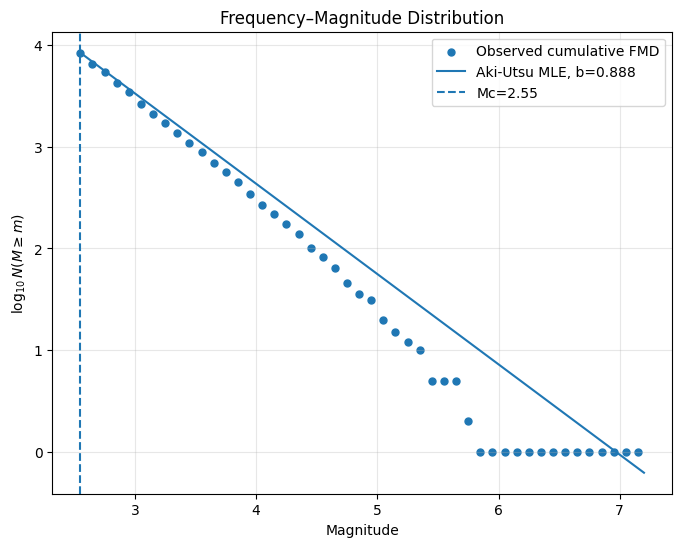

In [27]:
def plot_fmd(magnitudes, mc, delta_m=0.1):

    bins = np.arange(
        np.floor(np.min(magnitudes) / delta_m) * delta_m,
        np.ceil(np.max(magnitudes) / delta_m) * delta_m + delta_m,
        delta_m
    )

    counts, edges = np.histogram(
        magnitudes,
        bins=bins
    )

    centers = (edges[:-1] + edges[1:]) / 2

    cumulative = np.array([
        np.sum(magnitudes >= x)
        for x in centers
    ])

    valid = cumulative > 0

    plt.figure(figsize=(8, 6))

    plt.scatter(
        centers[valid],
        np.log10(cumulative[valid]),
        s=25,
        label="Observed cumulative FMD"
    )

    mfit = np.linspace(
        mc,
        np.max(magnitudes),
        100
    )

    b = results["Aki-Utsu"]

    a = results["a-value"]

    predicted = a - b * mfit

    plt.plot(
        mfit,
        predicted,
        label=f"Aki-Utsu MLE, b={b:.3f}"
    )

    plt.axvline(
        mc,
        linestyle="--",
        label=f"Mc={mc:.2f}"
    )

    plt.xlabel("Magnitude")
    plt.ylabel(r"$\log_{10} N(M \geq m)$")
    plt.title("Frequency–Magnitude Distribution")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


plot_fmd(magnitudes, MC, DELTA_M)

# Synthetic exponential catalog

In [28]:
rng = np.random.default_rng(42)

TRUE_B = 0.90
TRUE_BETA = TRUE_B * np.log(10)

N_SYNTH = 10000
MC_SYNTH = 2.5
DELTA_M_SYNTH = 0.1

# Continuous Gutenberg-Richter magnitudes
m_synth = (
    MC_SYNTH
    + rng.exponential(
        scale=1 / TRUE_BETA,
        size=N_SYNTH
    )
)

# Round to catalog magnitude precision
m_synth = (
    np.round(m_synth / DELTA_M_SYNTH)
    * DELTA_M_SYNTH
)

print("True b =", TRUE_B)
print("Synthetic N =", len(m_synth))

True b = 0.9
Synthetic N = 10000


# Synthetic estimator comparison

In [29]:
synth_aki = aki_utsu_b(
    m_synth,
    MC_SYNTH,
    DELTA_M_SYNTH
)

synth_tm = tinti_mulargia_b(
    m_synth,
    MC_SYNTH,
    DELTA_M_SYNTH
)

synth_sigma = shi_bolt_sigma_b(
    m_synth,
    MC_SYNTH,
    DELTA_M_SYNTH
)

synth_ols = fmd_ols_bvalue(
    m_synth,
    MC_SYNTH,
    DELTA_M_SYNTH
)["b"]

synthetic_results = pd.DataFrame({
    "Method": [
        "True",
        "Aki-Utsu",
        "Tinti-Mulargia",
        "OLS"
    ],
    "b": [
        TRUE_B,
        synth_aki,
        synth_tm,
        synth_ols
    ]
})

synthetic_results

,Method,b
0,True,0.900000
1,Aki-Utsu,0.825890
2,Tinti-Mulargia,4.342943
3,OLS,0.909899


In [30]:
print(f"True b              = {TRUE_B:.4f}")
print(f"Aki-Utsu             = {synth_aki:.4f}")
print(f"Tinti-Mulargia       = {synth_tm:.4f}")
print(f"Shi-Bolt sigma       = {synth_sigma:.4f}")
print(f"OLS                  = {synth_ols:.4f}")

print(
    "\nAki-Utsu within 1-sigma:",
    abs(synth_aki - TRUE_B) <= synth_sigma
)

True b              = 0.9000
Aki-Utsu             = 0.8259
Tinti-Mulargia       = 4.3429
Shi-Bolt sigma       = 0.0001
OLS                  = 0.9099

Aki-Utsu within 1-sigma: False


Automatic validation

In [31]:
def validate_bvalue(
    estimate,
    truth,
    sigma,
    name
):
    difference = abs(estimate - truth)

    passed = difference <= sigma

    print(
        f"{name:20s} "
        f"b={estimate:.4f} "
        f"| error={difference:.4f} "
        f"| sigma={sigma:.4f} "
        f"| {'PASS' if passed else 'CHECK'}"
    )


validate_bvalue(
    synth_aki,
    TRUE_B,
    synth_sigma,
    "Aki-Utsu"
)

validate_bvalue(
    synth_tm,
    TRUE_B,
    synth_sigma,
    "Tinti-Mulargia"
)

Aki-Utsu             b=0.8259 | error=0.0741 | sigma=0.0001 | CHECK
Tinti-Mulargia       b=4.3429 | error=3.4429 | sigma=0.0001 | CHECK
